# Imports and global configuration


In [ ]:
# sudo apt-get install -y gcc python3-dev

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re
import pygraphviz


from pathlib import Path
from scipy.stats import pearsonr
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.font_manager as fm
from networkx.utils import UnionFind
from networkx.drawing.nx_agraph import graphviz_layout
from collections import Counter
from matplotlib.colors import Normalize,LinearSegmentedColormap

In [2]:
# English implementation note.
def load_and_validate_data(file_path,test):
    """
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    """
    try:
        # English implementation note.
        data = pd.read_csv(file_path, header=0, index_col=0)

        # English implementation note.
        if data.empty:
            raise ValueError("数据为空！请检查 CSV 文件内容")
        if test == 'test1' or test == 'allcelltypes':
            celltype_info = data['celltype']
            data = data.drop(columns = 'celltype')
        # English implementation note.
        row_ids = data.index.values  # English implementation note.
        col_ids = data.columns.values  # English implementation note.
        print(np.array(row_ids, dtype=np.float64).round().astype(int))
        try:
            row_ids_int = np.array(row_ids, dtype=np.float64).round().astype(int)
            col_ids_int = np.array(col_ids, dtype=np.float64).round().astype(int)
        except ValueError:
            raise ValueError("细胞 ID 必须为整数格式（如 0,1,2...）")

        # English implementation note.
        if data.shape[0] != data.shape[1]:
            raise ValueError(f"相关性矩阵必须为方阵，当前为{data.shape[0]}行×{data.shape[1]}列")

        # English implementation note.
        if VERBOSE:
            print(f"✅ 数据加载成功！共{len(row_ids)}个细胞，矩阵维度{data.shape[0]}×{data.shape[1]}")
        if test =='test1':
            return data,(row_ids,celltype_info)
        else:
            return data, (row_ids_int, celltype_info)  # English implementation note.

    except Exception as e:
        print(f"❌ 数据加载失败：{str(e)}")
        raise  # English implementation note.


In [3]:
def plot_significant_total_ratio(data, alpha):#therehol test is abanded
    # selected upper trangle data
    print('进行显著性筛选:')
    upper_triangle_indices = np.triu_indices_from(data, k=1)
    linear_data = data.values[upper_triangle_indices]
    mean = np.mean(linear_data)
    std = np.std(linear_data)
    # significance test(FDR)
    z_scores = stats.zscore(linear_data)  # English implementation note.
    plt.hist(z_scores, bins=50, alpha=0.7, color='blue')
    plt.title('Z-score Distribution')
    plt.xlabel('Z-score')
    
    # English implementation note.
    p_values = stats.norm.sf(z_scores)
    print(f'P值最大{min(p_values)}P值最小{max(p_values)}')
    # English implementation note.
    mask = p_values < alpha
    #mask,corrected_p,_,_= multipletests(p_values, alpha=0.05, method='fdr_bh')
    sig_counts = []
    edge_counts = []


    # English implementation note.
    survived = linear_data[mask]
    print(survived)

    mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)

# English implementation note.
    mask_2d[np.triu_indices_from(data, k=1)] = mask

    # English implementation note.
    mask_2d = mask_2d | mask_2d.T
        
    return mask_2d,mask,p_values


In [ ]:
def  plot_thershold(data,threshold):
     print('Performing thresholding:')
     upper_triangle_indices = np.triu_indices_from(data, k=1)
     linear_data = data.values[upper_triangle_indices]
     plt.hist(linear_data, bins=50, color='skyblue', edgecolor='black')
     plt.axvline(x=threshold, color='red', linestyle='--', label=f'Treshold = {threshold}')
     plt.title('Correlation Coefficient Distribution')
     plt.xlabel('Correlation Coefficient')
     plt.ylabel('Frequency')
     plt.show()
     # significance test(FDR)
     # English implementation note.
     mask = linear_data >= threshold
     #mask,corrected_p,_,_= multipletests(p_values, alpha=0.05, method='fdr_bh')
     # English implementation note.
     mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)

# English implementation note.
     mask_2d[np.triu_indices_from(data, k=1)] = mask

    # English implementation note.
     mask_2d = mask_2d | mask_2d.T
        
     return mask_2d,mask


In [5]:
def find_Threshold(lst):
    indices = [i for i, value in enumerate(lst) if value == 1]
    if indices:
        return indices[0]  # English implementation note.
    else:
        return max(lst)

In [ ]:
def binarize_matrix(matrix, mask):
    """
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    """
    if VERBOSE:
        print(f"")
    # English implementation note.
    binary_matrix = matrix.copy()
    
    # English implementation note.
    binary_matrix[mask ==True] = 1
    binary_matrix[mask == False] = 0
    
    # English implementation note.
    np.fill_diagonal(binary_matrix, 0)
    
    # English implementation note.
    total_edges = int(np.sum(binary_matrix) / 2)
    if VERBOSE:
        print(f"✅ Network contains {total_edges} valid connections after binarization.")
    
    return binary_matrix



In [7]:
def get_weight_matrix(matrix, mask):
    weight_matrix = matrix.copy()
    
    # English implementation note.
    # English implementation note.
    weight_matrix[~mask] = 0  # English implementation note.
    
    # English implementation note.
    np.fill_diagonal(weight_matrix, 0)
    return weight_matrix

In [8]:
def analyze_network(adjacency_matrix, cell_ids):
    """
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    """
    try:
        if VERBOSE:
            print("\n🔬 开始网络拓扑属性分析...")
        
        # English implementation note.
        G = nx.from_numpy_array(adjacency_matrix, create_using=nx.Graph())
        G = nx.relabel_nodes(G, {i: cell_id for i, cell_id in enumerate(range(len(cell_ids)))})
        
        
        # English implementation note.
        connected_components = list(nx.connected_components(G))  # English implementation note.
        num_components = len(connected_components)  # English implementation note.
        components_len = [len(c) for c in connected_components]
        component_map = {}  # English implementation note.
        for comp_id, component in enumerate(connected_components):
            for node in component:
                component_map[node] = (comp_id, components_len[comp_id])

        # English implementation note.
        node_df = pd.DataFrame({
            "Cell_ID": list(G.nodes),
            "Clustering_Coefficient": list(nx.clustering(G).values()),  # English implementation note.
            "Degree": [deg for _, deg in G.degree()],  # English implementation note.
            "Betweenness_Centrality": list(nx.betweenness_centrality(G).values()), # English implementation note.
            "Component": [component_map[node][0] for node in G.nodes],
            "Component_length": [component_map[node][1] for node in G.nodes]   # English implementation note.
        })
        
        
        # English implementation note.
        if connected_components:
            max_comp_nodes = max(connected_components, key=len)
            G_max_comp = G.subgraph(max_comp_nodes)
            # if len(max_comp_nodes) > 1:
            # English implementation note.
            #     shortest_paths = dict(nx.all_pairs_shortest_path_length(G_max_comp))
            #     path_lengths = [shortest_paths[u][v] for u in G_max_comp.nodes() for v in G_max_comp.nodes() if u != v]
            #     char_path_length = np.mean(path_lengths)
            # else:
            # English implementation note.
        else:
            max_comp_nodes = []
            char_path_length = 0.0
        
        # English implementation note.
        network_df = pd.DataFrame([{
            "Total_Nodes": G.number_of_nodes(),
            "Total_Edges": G.number_of_edges(),
            "Total_Components": num_components,
            "Components_Lengths": np.sort(components_len),
            "Max_Component_Size": len(max_comp_nodes),
        }])

        if VERBOSE:
            print("✅ 网络分析完成！关键指标：")
            for value in network_df.columns:
                print(f"{value}: {network_df.iloc[0][value]}")

        return G, node_df, network_df  # English implementation note.

    except Exception as e:
        print(f"❌ 网络分析失败：{str(e)}")
        raise


In [9]:
def spanning_forest_unweighted(G):
    sf = nx.Graph()
    sf.add_nodes_from(G.nodes())
    uf = UnionFind(G.nodes())
    for u, v in G.edges():
        if uf[u] != uf[v]:
            sf.add_edge(u, v)
            uf.union(u, v)
    return sf

In [10]:
def minimum_spanning_forest_weighted(G):
    """English documentation is provided by the function name and surrounding code."""
    msf = nx.Graph()
    msf.add_nodes_from(G.nodes())  # English implementation note.
    
    # English implementation note.
    for component in nx.connected_components(G):
        subgraph = G.subgraph(component)
        # English implementation note.
        mst = nx.minimum_spanning_tree(subgraph, weight='weight')
        msf.add_edges_from(mst.edges(data=True))  # English implementation note.
    return msf

In [11]:
def find_key_cells(node_metrics, top_n=10):
    """
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    English documentation is provided by the function name and surrounding code.
    """
    if VERBOSE:
        print(f"\n🔍 筛选网络中的关键细胞（前{top_n}个）...")
    
    # English implementation note.
    betweenness_sorted = sorted(
        node_metrics["Betweenness_Centrality"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    betweenness_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in betweenness_sorted],
        "Betweenness_Centrality": [round(val, 4) for cid, val in betweenness_sorted],
        "Degree": [node_metrics["Degree"][cid] for cid, val in betweenness_sorted]
    })
    
    # English implementation note.
    degree_sorted = sorted(
        node_metrics["Degree"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    degree_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in degree_sorted],
        "Degree": [val for cid, val in degree_sorted],
        "Clustering_Coefficient": [round(node_metrics["Clustering_Coefficient"][cid], 4) for cid, val in degree_sorted]
    })
    
    return betweenness_top, degree_top


In [12]:
# def R2ized_matrix(matrix,theresold):
#     r2_matrix = np.zeros_like(matrix)
# # find R2
#     for i in range(matrix.shape[0]):
#         for j in range(matrix.shape[1]):
# English implementation note.
# English implementation note.
#                 x = matrix.iloc[i, :].values.reshape(-1, 1)
# English implementation note.
#                 y = matrix.iloc[:, j].values

# English implementation note.
#                 model = LinearRegression()
#                 model.fit(x, y)
#                 y_pred = model.predict(x)
#                 r2 = r2_score(y, y_pred)
# English implementation note.
#                 r2_matrix[i, j] = r2
#             else:
#                 r2_matrix[i, j] = 1
#     r2_df = pd.DataFrame(r2_matrix, index=matrix.index, columns=matrix.columns)
# English implementation note.
#     sig_matrix = np.zeros_like(matrix)
#     sig_matrix[ r2_df > theresold] = 1
#     sig_df = pd.DataFrame(sig_matrix, index=matrix.index, columns=matrix.columns)
#     total_edges = int(np.sum(sig_matrix) / 2)
# English implementation note.
#     return sig_matrix

# R2_mat = R2ized_matrix(data,0.1)
# R2_mat

In [ ]:
# 1. filepath
#LHQ30,LHQ50,LH5799,LH5798,LH5779,LH0167,LH0166
#CSDS5797,,CSDSQ29,CSDSQ27,CSDSQ26,CSDS5776,CSDS0370

global VERBOSE
VERBOSE =  True  # English implementation note.
projectpath = r"G:\XJN_M2project"
ids = [  #"CSDS5797" ]  # empty line for test
    "LHQ30", "LHQ50", "LH5799", "LH5798", "LH5779", "LH0167", "LH0166",
    "CSDS5797", "CSDSQ29", "CSDSQ27", "CSDSQ26", "CSDS5776", "CSDS0370"
]
conditions = ['pre', 'post', 'rescue']
test = 'allcelltypes'

Getting network metrics for S_to_I
[103  96  77 ...  28  84  35]
✅ 数据加载成功！共2359个细胞，矩阵维度2359×2359
进行阈值筛选:


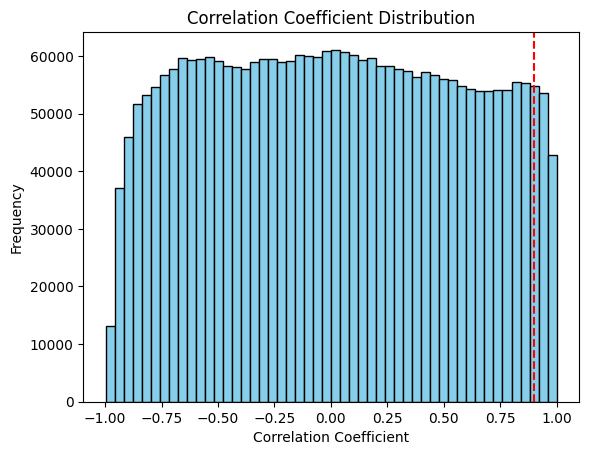


🔬 开始网络拓扑属性分析...
✅ 网络分析完成！关键指标：
Total_Nodes: 2359
Total_Edges: 124043
Total_Components: 637
Components_Lengths: [   1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1 

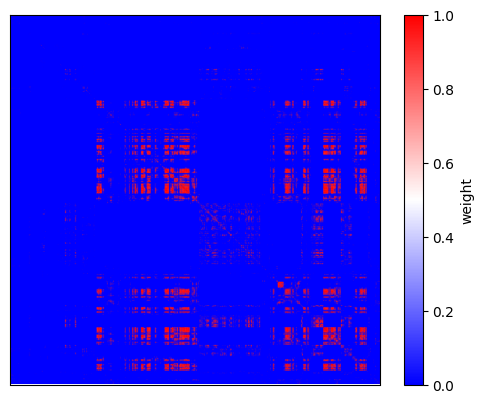

In [ ]:

event_type = 'S_to_I'#S_to_I,I_to_S

threshold = 0.9

INPUT_FILE_PATH = os.path.join(projectpath,'correlation_analysis', test, f'{event_type}_correlation_matrix.csv')
if not os.path.exists(INPUT_FILE_PATH):
    print(f"WARNING: Input file not found: {INPUT_FILE_PATH}")
print(f'Getting network metrics for {event_type}')
OUTPUT_FILE_PATH = os.path.join(projectpath ,'correlation_analysis', test , f'{event_type}_network_metrics_result.csv')
# notebook 
SHOW_VISUALIZATION = True  # English implementation note.

# English implementation note.
data, id_info = load_and_validate_data(INPUT_FILE_PATH,test)
if test == 'test1' or test == 'allcelltypes':
    cell_ids = id_info[0]
else:
    cell_ids = id_info
# English implementation note.
mask_2d,mask = plot_thershold(data, threshold)
plt.close('all')


# English implementation note.
weight_matrix = get_weight_matrix(data.values, mask_2d)
plt.imshow(weight_matrix,cmap='bwr')
plt.colorbar(label='weight')# English implementation note.
plt.xticks([])  # English implementation note.
plt.yticks([])
# English implementation note.
G, node_df, network_df = analyze_network(weight_matrix, cell_ids)


PLOTTING

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_44308\3534577006.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_correaltion_graph.pdf


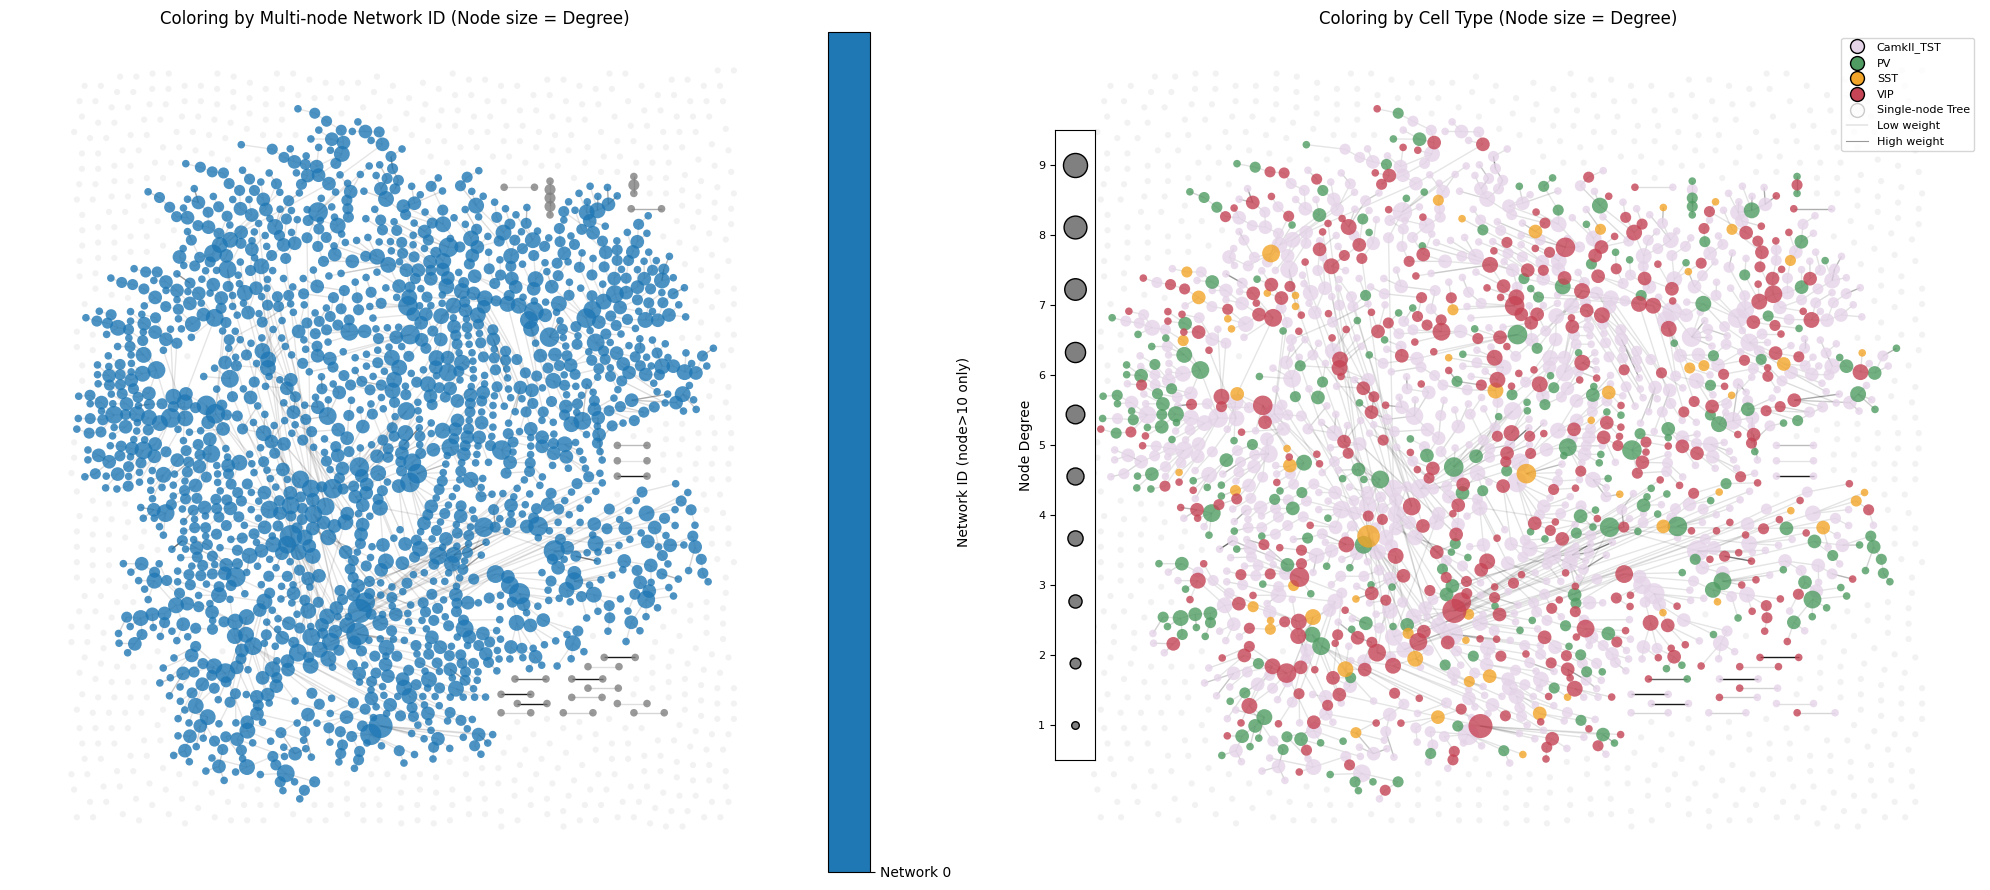

生成森林包含 637 棵树
其中单节点树 617 棵，多节点树 1 棵
边权重统计：均值=0.3152，范围=[0.3000, 0.8000]
多节点度值统计：均值=1.98，范围=[1, 9]


In [17]:

# English implementation note.
n_neurons = weight_matrix.shape[0]
cell_types = node_df['celltype'].values

# English implementation note.
G = nx.Graph()
G.add_nodes_from(range(n_neurons))
for i in range(n_neurons):
    for j in range(i+1, n_neurons):
        if (w := weight_matrix[i, j]) != 0:
            G.add_edge(i, j, weight=w)

# English implementation note.
sf = minimum_spanning_forest_weighted(G)
sf_components = list(nx.connected_components(sf))
multi_node_components = [c for c in sf_components if len(c) > 10]

# English implementation note.
multi_node_id_map = {n: i for i, comp in enumerate(multi_node_components) for n in comp}
node_tree_id = [multi_node_id_map.get(n, -1) for n in sf.nodes()]

# English implementation note.
G_components = list(nx.connected_components(G))
comp_info = {n: (i, len(c)) for i, c in enumerate(G_components) for n in c}


# English implementation note.
max_comp_nodes = max(G_components, key=len) if G_components else []

# English implementation note.
lonely_node_ids = set(n for c in G_components if len(c)==1 for n in c)
node_degrees = dict(sf.degree())

# English implementation note.
min_size, max_size, fixed_single_size = 30, 300, 20
multi_degs = [d for n, d in node_degrees.items() if n not in lonely_node_ids]

if multi_degs:
    min_d, max_d = min(multi_degs), max(multi_degs)
    node_sizes = [fixed_single_size if n in lonely_node_ids else 
                 min_size + (max_size - min_size)*(d - min_d)/(max_d - min_d + 1e-8)
                 for n, d in node_degrees.items()]
else:
    node_sizes = [fixed_single_size] * len(node_degrees)

# English implementation note.
cmap_tree = plt.cm.tab10
node_colors_id = ['gray' if tid == -1 else cmap_tree(tid % cmap_tree.N) 
                 for tid in node_tree_id]
color_map_cell = {1: '#E5D4E8', 2: '#4F9B62', 3: '#F2A529', 4: '#C54455'}
node_colors_cell = ['gray' if n in lonely_node_ids else color_map_cell[cell_types[n]]
                   for n in sf.nodes()]

edges = sf.edges(data=True)
weights = [d['weight'] for u, v, d in edges]
min_weight = np.min(weights)
max_weight = np.max(weights)
weights = [((n-min_weight)/(max_weight-min_weight))*0.5+0.3 for n in weights] # English implementation note.
cmap = plt.cm.Greys

alphas = [0.1 if n in lonely_node_ids else 0.8 for n in sf.nodes()]

line_alphas = []

for i, (u, v, corr_val) in enumerate(edges):
            normalized = (corr_val['weight'] - min_weight) / (max_weight - min_weight)
            alpha = 0.1 + 0.8 * normalized  # English implementation note.
            line_alphas.append(alpha)

# English implementation note.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
pos = graphviz_layout(sf, prog='twopi', args='-Goverlap=prism -Gnodesep=200')

# English implementation note.
nx.draw_networkx_nodes(sf, pos, ax=ax1, node_size=node_sizes, node_color=node_colors_id,
                      edgecolors='none', alpha=alphas, linewidths=alphas)
nx.draw_networkx_edges(sf, pos, ax=ax1, edge_color='black', alpha=line_alphas)

# English implementation note.
if (n_multi := len(multi_node_components)) > 0:
    used_ids = range(min(n_multi, cmap_tree.N))
    sm = plt.cm.ScalarMappable(cmap=mpl.colors.ListedColormap([cmap_tree(i) for i in used_ids]))
    cbar = plt.colorbar(sm, ax=ax1, ticks=used_ids)
    cbar.set_ticklabels([f'Network {i}' for i in used_ids])
    cbar.set_label('Network ID (node>10 only)', fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No multi-node networks', ha='center', va='center', transform=ax1.transAxes)

ax1.set_title('Coloring by Multi-node Network ID (Node size = Degree)', fontsize=12)
ax1.axis('off')

# English implementation note.
nx.draw_networkx_nodes(sf, pos, ax=ax2, node_size=node_sizes, node_color=node_colors_cell,
                      edgecolors='none', alpha=alphas, linewidths=alphas)
nx.draw_networkx_edges(sf, pos, ax=ax2, edge_color='black', alpha=line_alphas)

# English implementation note.
cellnames = ['CamkII_TST','PV','SST','VIP']
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=cellnames[i],
              markerfacecolor=c, markersize=10, markeredgecolor='black')
    for i, c in enumerate(color_map_cell.values())
] + [
    plt.Line2D([0], [0], marker='o', color='w', label='Single-node Tree',
              markerfacecolor='#F0F0F0', markersize=10, markeredgecolor='black', alpha=0.2),
    plt.Line2D([0,1], [0,0], color='#999999', linewidth=min(weights), label='Low weight'),
    plt.Line2D([0,1], [0,0], color='#999999', linewidth=max(weights), label='High weight'),
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax2.set_title('Coloring by Cell Type (Node size = Degree)', fontsize=12)
ax2.axis('off')

# English implementation note.
if multi_degs:
    cax = fig.add_axes([0.53, 0.15, 0.02, 0.7])
    for s, d in zip(np.linspace(min_size, max_size, 10), np.linspace(min_d, max_d, 10)):
        cax.scatter([0], [d], s=s, color='gray', edgecolors='black')
    cax.set(ylim=(min_d-0.5, max_d+0.5), xlim=(-0.5, 0.5), xticks=[], ylabel='Node Degree')
    cax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(Path(OUTPUT_FILE_PATH).parent,f'{event_type}_correaltion_graph.pdf'))
print(f'Figure saved to {os.path.join(Path(OUTPUT_FILE_PATH).parent,f"{event_type}_correaltion_graph.pdf")}')
plt.show()

# English implementation note.
print(f"生成森林包含 {len(G_components)} 棵树")
print(f"其中单节点树 {len([c for c in G_components if len(c)==1])} 棵，多节点树 {n_multi} 棵")
if 'weights' in locals() and weights:
    print(f"边权重统计：均值={np.mean(weights):.4f}，范围=[{min(weights):.4f}, {max(weights):.4f}]")
if multi_degs:
    print(f"多节点度值统计：均值={np.mean(multi_degs):.2f}，范围=[{min_d}, {max_d}]")



⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含124043条有效连接
Number of neurons after processing: 2359
CamKII node count: 1516
Cell type distribution: [   0 1516  341   73  429]
Adjacency matrix shape: (2359, 2359)


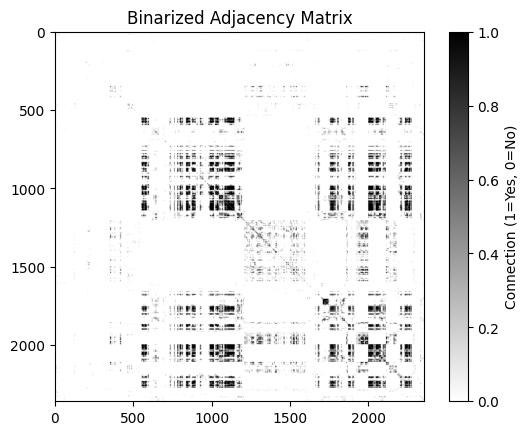

CamKII edge composition totals:
  PV: 15399
  SST: 6457
  VIP: 38229


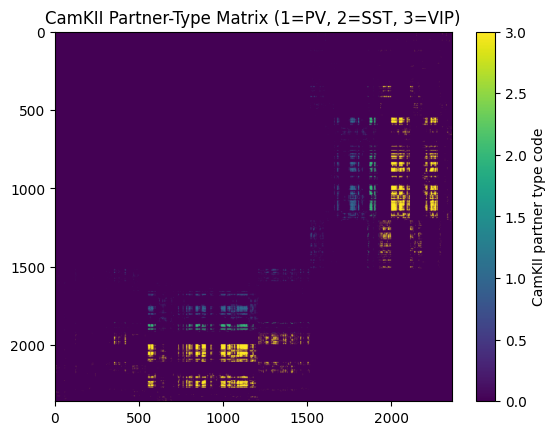

Number of graph nodes: 2359, number of edges: 124043
Number of connected components: 637


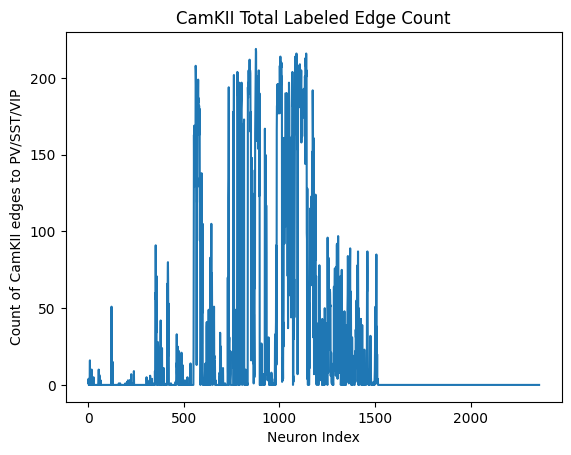

CamKII labeled edge count range: [0.00, 219.00]
Node degree range: [0, 470]


In [18]:
from matplotlib.colors import Normalize

# Process data as required:
# summarize CamKII(celltype 1) connections to PV/SST/VIP as per-node proportions.
n_neurons = len(cell_types)
adjacency_matrix = binarize_matrix(data.values, mask_2d)
camkii_nodes = np.where(cell_types == 1)[0]
partner_type_to_channel = {2: 0, 3: 1, 4: 2}  # R, G, B
channel_names = ['PV', 'SST', 'VIP']
channel_colors = {
    'PV': '#4F9B62',
    'SST': '#F2A529',
    'VIP': '#C54455',
}

print(f"Number of neurons after processing: {n_neurons}")
print(f"CamKII node count: {len(camkii_nodes)}")
print(f"Cell type distribution: {np.bincount(cell_types)}")
print(f"Adjacency matrix shape: {adjacency_matrix.shape}")

plt.imshow(adjacency_matrix, cmap='gray_r')
plt.title('Binarized Adjacency Matrix')
plt.colorbar(label='Connection (1=Yes, 0=No)')
plt.show()

# 0=no labeled CamKII edge, 1=PV, 2=SST, 3=VIP
camkii_partner_code = np.zeros((n_neurons, n_neurons), dtype=int)
camkii_edge_counts = np.zeros((n_neurons, 3), dtype=int)

for i in range(n_neurons):
    for j in range(i + 1, n_neurons):
        if adjacency_matrix[i, j] != 1:
            continue

        type_i = cell_types[i]
        type_j = cell_types[j]

        if type_i == 1 and type_j in partner_type_to_channel:
            channel_idx = partner_type_to_channel[type_j]
            camkii_partner_code[i, j] = channel_idx + 1
            camkii_partner_code[j, i] = channel_idx + 1
            camkii_edge_counts[i, channel_idx] += 1
        elif type_j == 1 and type_i in partner_type_to_channel:
            channel_idx = partner_type_to_channel[type_i]
            camkii_partner_code[i, j] = channel_idx + 1
            camkii_partner_code[j, i] = channel_idx + 1
            camkii_edge_counts[j, channel_idx] += 1

print("CamKII edge composition totals:")
for idx, name in enumerate(channel_names):
    print(f"  {name}: {camkii_edge_counts[:, idx].sum()}")

plt.imshow(camkii_partner_code, cmap='viridis', aspect='auto')
plt.colorbar(label='CamKII partner type code')
plt.title('CamKII Partner-Type Matrix (1=PV, 2=SST, 3=VIP)')
plt.show()

G = nx.Graph()
G.add_nodes_from(range(n_neurons))
for i in range(n_neurons):
    for j in range(i + 1, n_neurons):
        if adjacency_matrix[i, j] == 1:
            G.add_edge(i, j, weight=weight_matrix[i, j])

print(f"Number of graph nodes: {G.number_of_nodes()}, number of edges: {G.number_of_edges()}")

G_components = list(nx.connected_components(G))
comp_info = {n: (i, len(c)) for i, c in enumerate(G_components) for n in c}
print(f"Number of connected components: {len(G_components)}")

# node_values keeps total labeled CamKII edges for compatibility with later cells.
node_values = camkii_edge_counts.sum(axis=1).astype(float)
camkii_edge_proportions = np.zeros((n_neurons, 3), dtype=float)
for i in camkii_nodes:
    total_edges = node_values[i]
    if total_edges > 0:
        camkii_edge_proportions[i] = camkii_edge_counts[i] / total_edges

# Backward-compatible alias for older downstream cells; no longer used as RGB colors.
camkii_rgb_values = camkii_edge_proportions

plt.plot(node_values)
plt.title('CamKII Total Labeled Edge Count')
plt.xlabel('Neuron Index')
plt.ylabel('Count of CamKII edges to PV/SST/VIP')
plt.show()

node_degrees = dict(G.degree())
print(f"CamKII labeled edge count range: [{np.min(node_values):.2f}, {np.max(node_values):.2f}]")
print(f"Node degree range: [{min(node_degrees.values())}, {max(node_degrees.values())}]")

lonely_node_ids = set(n for c in G_components if len(c) == 1 for n in c)

min_size, max_size, fixed_single_size = 30, 200, 20
multi_degs = [d for n, d in node_degrees.items() if n not in lonely_node_ids]

if multi_degs:
    min_d, max_d = min(multi_degs), max(multi_degs)
    node_sizes = [
        fixed_single_size if n in lonely_node_ids else
        min_size + (max_size - min_size) * (d - min_d) / (max_d - min_d + 1e-8)
        for n, d in node_degrees.items()
    ]
else:
    node_sizes = [fixed_single_size] * len(node_degrees)

node_colors = []
node_edgecolors = []
node_linewidths = []
for i in range(n_neurons):
    cell_type = cell_types[i]
    if i in lonely_node_ids:
        node_colors.append('#D9D9D9')
        node_edgecolors.append('#D9D9D9')
        node_linewidths.append(0.0)
    elif cell_type == 1:
        node_colors.append('#F2F2F2')
        node_edgecolors.append('black')
        node_linewidths.append(0.3)
    else:
        node_colors.append('#FFFFFF')
        node_edgecolors.append('#FFFFFF')
        node_linewidths.append(0.0)

edges = list(G.edges(data=True))
weights = [abs(d['weight']) for _, _, d in edges]
if weights:
    min_weight, max_weight = min(weights), max(weights)
    edge_widths = [0.3 + 1.2 * (w - min_weight) / (max_weight - min_weight + 1e-8) for w in weights]
else:
    edge_widths = []

edge_colors = []
for u, v, _ in edges:
    edge_code = camkii_partner_code[u, v]
    if edge_code == 1:
        edge_colors.append(channel_colors['PV'])
    elif edge_code == 2:
        edge_colors.append(channel_colors['SST'])
    elif edge_code == 3:
        edge_colors.append(channel_colors['VIP'])
    else:
        edge_colors.append('#BDBDBD')

alphas = [0.15 if n in lonely_node_ids else 1.0 for n in G.nodes()]

composition_df = pd.DataFrame({
    'Cell_ID': np.arange(n_neurons),
    'celltype': cell_types,
    'PV_edges': camkii_edge_counts[:, 0],
    'SST_edges': camkii_edge_counts[:, 1],
    'VIP_edges': camkii_edge_counts[:, 2],
    'Total_labeled_edges': node_values.astype(int),
    'PV_proportion': camkii_edge_proportions[:, 0],
    'SST_proportion': camkii_edge_proportions[:, 1],
    'VIP_proportion': camkii_edge_proportions[:, 2],
})
composition_df = composition_df[composition_df['celltype'] == 1].reset_index(drop=True)

# RGB class labels are intentionally removed. Each partner type is visualized separately
# with a fixed color and alpha proportional to its per-node edge fraction.



In [19]:
composition_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_CamKII_edge_composition.csv'
)
print(f'Saving CamKII edge composition to {composition_output_path}')
composition_df.to_csv(composition_output_path, index=False, encoding='utf-8-sig')
composition_df.head()


Saving CamKII edge composition to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_edge_composition.csv


,Cell_ID,celltype,PV_edges,SST_edges,VIP_edges,Total_labeled_edges,PV_proportion,SST_proportion,VIP_proportion
0,0,1,1,0,2,3,0.333333,0.0,0.666667
1,1,1,1,0,0,1,1.000000,0.0,0.000000
2,2,1,1,0,3,4,0.250000,0.0,0.750000
3,3,1,0,0,0,0,0.000000,0.0,0.000000
4,4,1,0,0,0,0,0.000000,0.0,0.000000


Figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_PV_proportion_alpha_map.pdf


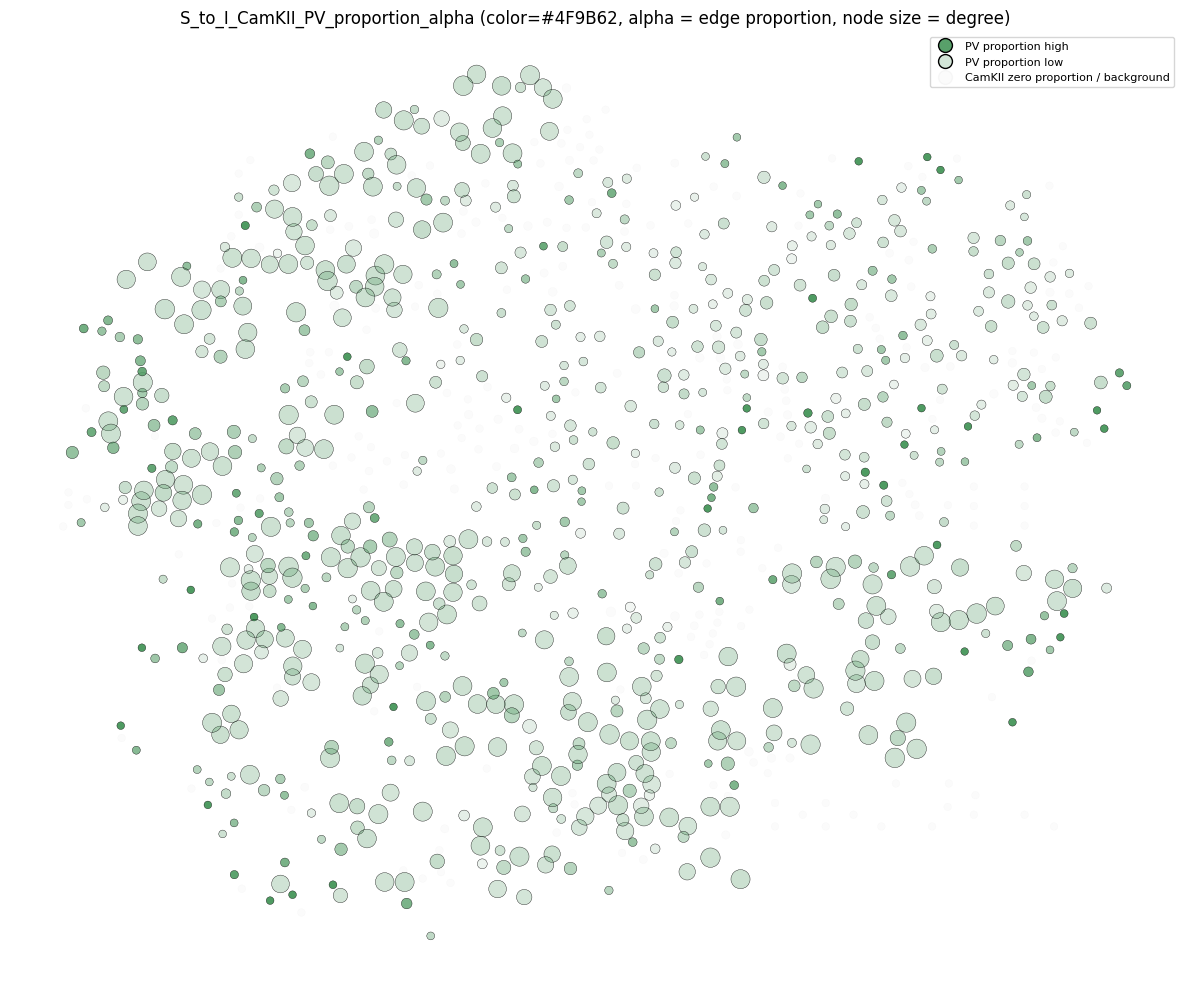

Figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_SST_proportion_alpha_map.pdf


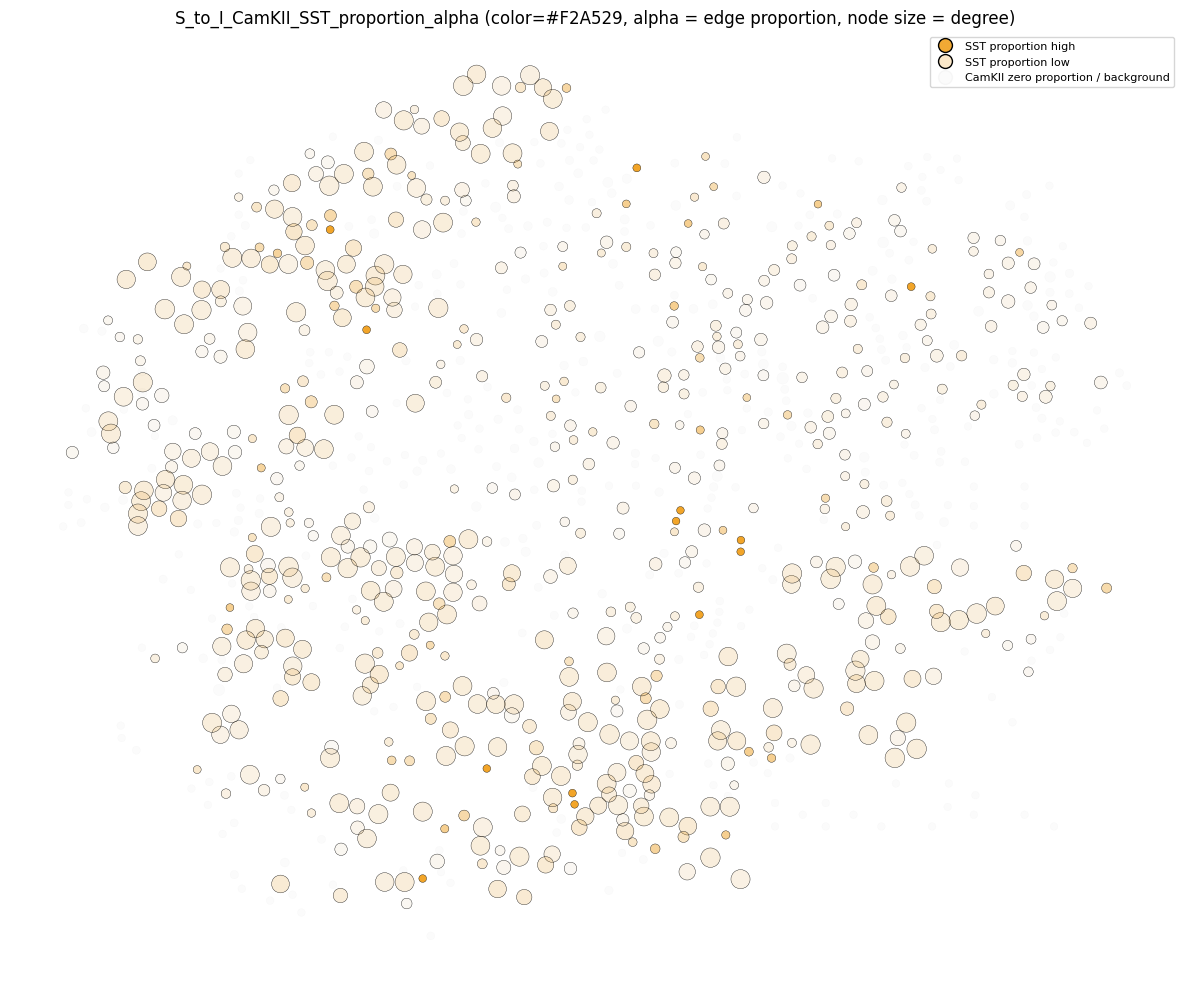

Figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_VIP_proportion_alpha_map.pdf


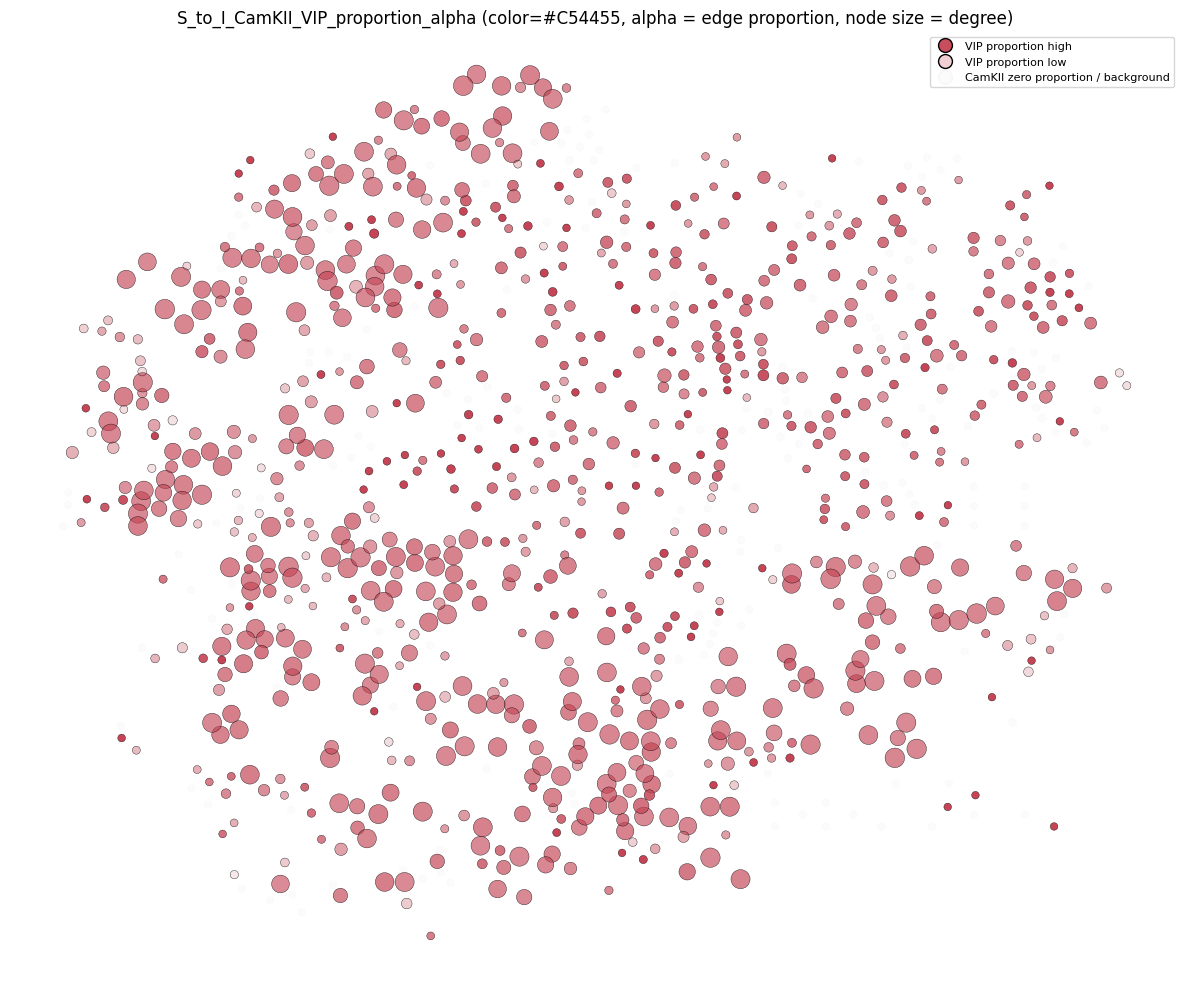

In [20]:
# ------------------------------
# 7. Visualization: separate CamKII alpha maps
# ------------------------------
np.random.seed(42)

camkii_node_set = set(camkii_nodes.tolist())
camkii_alpha_min = 0.02
camkii_alpha_max = 1.00
camkii_background_alpha = 0.10


def _draw_camkii_alpha_map(partner_name, channel_idx):
    fig, ax = plt.subplots(figsize=(12, 10))

    background_nodes = [n for n in G.nodes() if n in camkii_node_set and n not in lonely_node_ids]
    if background_nodes:
        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            nodelist=background_nodes,
            node_size=[node_sizes[n] for n in background_nodes],
            node_color='#D9D9D9',
            edgecolors='#BFBFBF',
            alpha=camkii_background_alpha,
            linewidths=0.2,
        )

    plotted_nodes = []
    plotted_colors = []
    for node in background_nodes:
        prop = float(camkii_edge_proportions[node, channel_idx])
        if prop <= 0:
            continue
        alpha = camkii_alpha_min + prop * (camkii_alpha_max - camkii_alpha_min)
        plotted_nodes.append(node)
        plotted_colors.append(mpl.colors.to_rgba(channel_colors[partner_name], alpha=alpha))

    if plotted_nodes:
        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            nodelist=plotted_nodes,
            node_size=[node_sizes[n] for n in plotted_nodes],
            node_color=plotted_colors,
            edgecolors='black',
            linewidths=0.25,
        )

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label=f'{partner_name} proportion high',
                   markerfacecolor=mpl.colors.to_rgba(channel_colors[partner_name], 0.95), markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', label=f'{partner_name} proportion low',
                   markerfacecolor=mpl.colors.to_rgba(channel_colors[partner_name], 0.25), markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', label='CamKII zero proportion / background',
                   markerfacecolor='#D9D9D9', alpha=camkii_background_alpha, markersize=10, markeredgecolor='#BFBFBF'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    ax.set_title(
        f'{event_type}_CamKII_{partner_name}_proportion_alpha '
        f'(color={channel_colors[partner_name]}, alpha = edge proportion, node size = degree)',
        fontsize=12,
    )
    ax.axis('off')
    plt.tight_layout()

    base_path = os.path.join(Path(OUTPUT_FILE_PATH).parent, f'{event_type}_CamKII_{partner_name}_proportion_alpha_map')
    # plt.savefig(f'{base_path}.pdf', bbox_inches='tight')
    print(f'Figure saved to {base_path}.pdf')
    plt.show()


for channel_idx, partner_name in enumerate(channel_names):
    _draw_camkii_alpha_map(partner_name, channel_idx)



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Composite figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_alpha_composite_overlay_and_single_maps.pdf
Composite figure saved to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_alpha_composite_overlay_and_single_maps.png


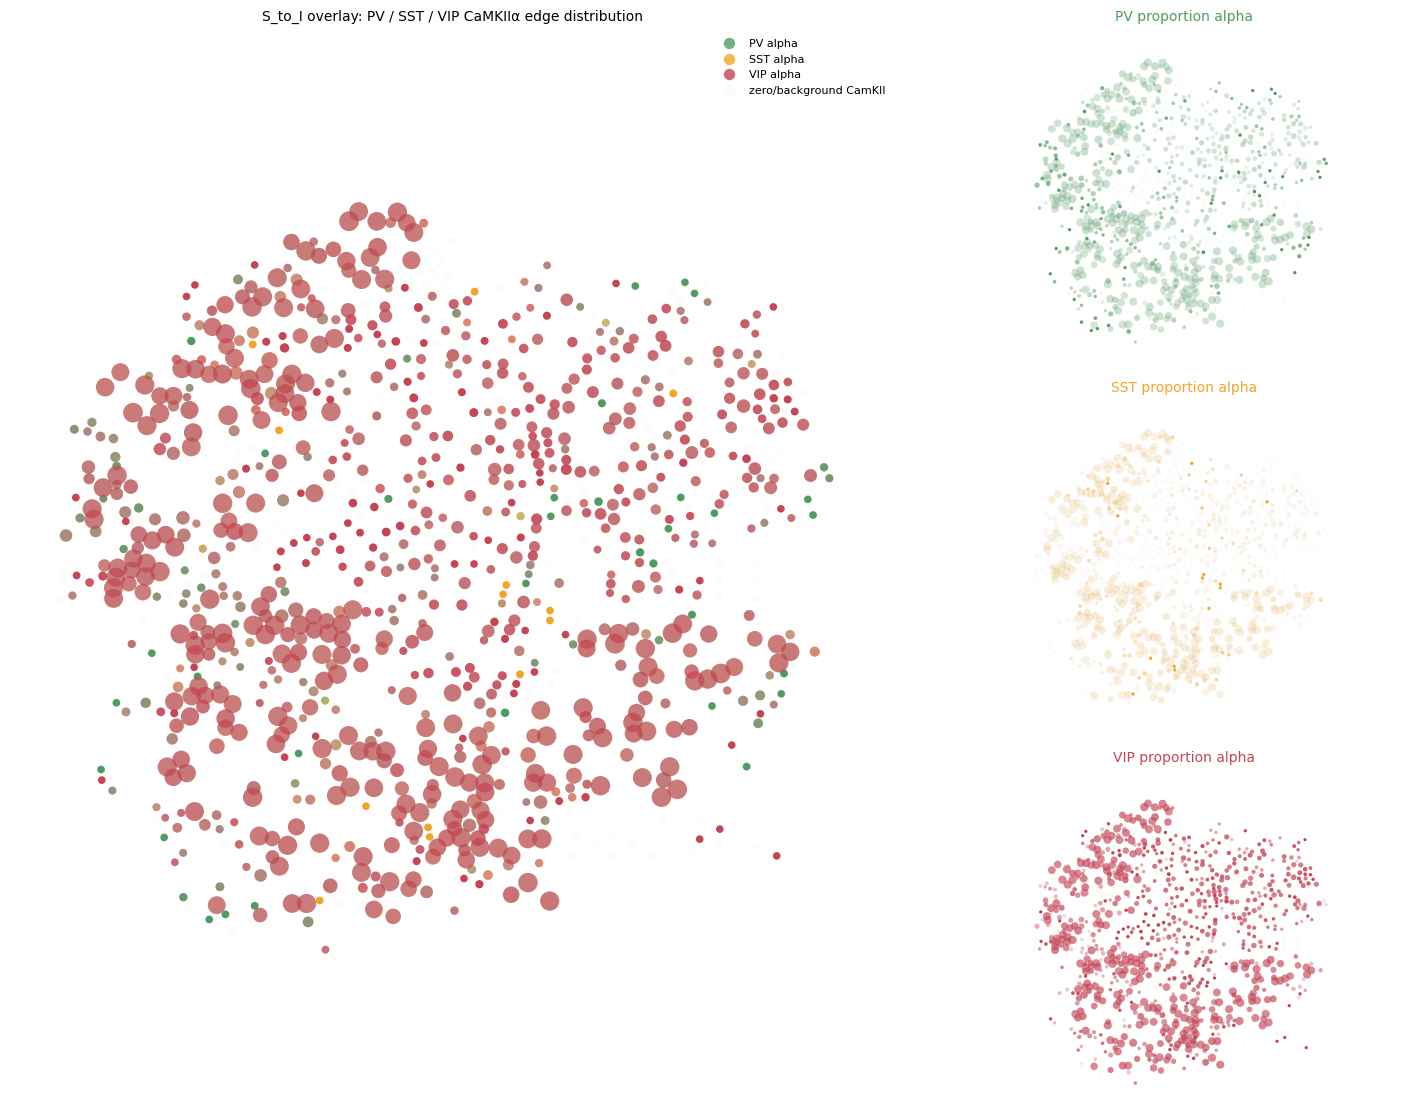

In [21]:
# ------------------------------
# 8. Visualization: composite overlay + three single-partner alpha maps
# ------------------------------

left_width_ratio = 2.0
right_width_ratio = 1.0
right_node_size_scale = 0.18
right_background_alpha = 0.10
overlay_background_alpha = 0.08


def _pos_limits(pos_dict, pad_fraction=0.04):
    xs = np.array([xy[0] for xy in pos_dict.values()], dtype=float)
    ys = np.array([xy[1] for xy in pos_dict.values()], dtype=float)
    x_min, x_max = float(np.nanmin(xs)), float(np.nanmax(xs))
    y_min, y_max = float(np.nanmin(ys)), float(np.nanmax(ys))
    x_pad = (x_max - x_min) * pad_fraction
    y_pad = (y_max - y_min) * pad_fraction
    return (x_min - x_pad, x_max + x_pad), (y_min - y_pad, y_max + y_pad)


def _format_network_axis(ax, draw_pos, title, title_color='black'):
    xlim, ylim = _pos_limits(draw_pos)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_anchor('W')
    ax.set_title(title, fontsize=10, color=title_color)
    ax.margins(0)
    ax.axis('off')


def _draw_camkii_background(ax, draw_pos, nodes, size_scale=1.0, alpha=0.08):
    if nodes:
        nx.draw_networkx_nodes(
            G, draw_pos, ax=ax,
            nodelist=nodes,
            node_size=[node_sizes[n] * size_scale for n in nodes],
            node_color='#D9D9D9',
            edgecolors='#BFBFBF',
            alpha=alpha,
            linewidths=0.2 * size_scale,
        )


def _draw_partner_alpha_layer(ax, draw_pos, nodes, partner_name, channel_idx, size_scale=1.0, with_edge=False):
    plotted_nodes = []
    plotted_colors = []
    for node in nodes:
        prop = float(camkii_edge_proportions[node, channel_idx])
        if prop <= 0:
            continue
        alpha = camkii_alpha_min + prop * (camkii_alpha_max - camkii_alpha_min)
        plotted_nodes.append(node)
        plotted_colors.append(mpl.colors.to_rgba(channel_colors[partner_name], alpha=alpha))

    if plotted_nodes:
        nx.draw_networkx_nodes(
            G, draw_pos, ax=ax,
            nodelist=plotted_nodes,
            node_size=[node_sizes[n] * size_scale for n in plotted_nodes],
            node_color=plotted_colors,
            edgecolors='black' if with_edge else 'none',
            linewidths=0.2 * size_scale if with_edge else 0,
        )


camkii_node_set = set(camkii_nodes.tolist())
background_nodes = [n for n in G.nodes() if n in camkii_node_set and n not in lonely_node_ids]

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[left_width_ratio, right_width_ratio],
    height_ratios=[1, 1, 1],
    wspace=0.10,
    hspace=0.10,
)

ax_overlay = fig.add_subplot(gs[:, 0])
right_axes = [fig.add_subplot(gs[i, 1]) for i in range(3)]

# Left: three partner layers overlaid. It uses the original coordinate aspect ratio.
_draw_camkii_background(ax_overlay, pos, background_nodes, size_scale=1.0, alpha=overlay_background_alpha)
for channel_idx, partner_name in enumerate(channel_names):
    _draw_partner_alpha_layer(ax_overlay, pos, background_nodes, partner_name, channel_idx, size_scale=1.0, with_edge=False)
_format_network_axis(
    ax_overlay,
    pos,
    f'{event_type} overlay: PV / SST / VIP CaMKIIα edge distribution',
)

# Right: individual partner maps. Coordinates are not compressed; only marker area is scaled down.
for ax, (channel_idx, partner_name) in zip(right_axes, enumerate(channel_names)):
    _draw_camkii_background(ax, pos, background_nodes, size_scale=right_node_size_scale, alpha=right_background_alpha)
    _draw_partner_alpha_layer(
        ax, pos, background_nodes, partner_name, channel_idx,
        size_scale=right_node_size_scale,
        with_edge=False,
    )
    _format_network_axis(
        ax,
        pos,
        f'{partner_name} proportion alpha',
        title_color=channel_colors[partner_name],
    )

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='PV alpha',
               markerfacecolor=mpl.colors.to_rgba(channel_colors['PV'], 0.8), markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', label='SST alpha',
               markerfacecolor=mpl.colors.to_rgba(channel_colors['SST'], 0.8), markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', label='VIP alpha',
               markerfacecolor=mpl.colors.to_rgba(channel_colors['VIP'], 0.8), markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', label='zero/background CamKII',
               markerfacecolor='#D9D9D9', alpha=right_background_alpha, markersize=9),
]
ax_overlay.legend(handles=legend_elements, loc='upper right', fontsize=8, frameon=False)

composite_output_path = os.path.join(Path(OUTPUT_FILE_PATH).parent, f'{event_type}_CamKII_alpha_composite_overlay_and_single_maps')
plt.savefig(f'{composite_output_path}.pdf', bbox_inches='tight')
print(f'Composite figure saved to {composite_output_path}.pdf')
print(f'Composite figure saved to {composite_output_path}.png')
plt.show()



In [22]:
multi_degs

[8,
 4,
 8,
 4,
 5,
 4,
 4,
 1,
 9,
 22,
 1,
 2,
 13,
 20,
 8,
 2,
 6,
 9,
 2,
 2,
 13,
 17,
 3,
 10,
 1,
 1,
 1,
 7,
 75,
 33,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 2,
 3,
 3,
 1,
 3,
 3,
 4,
 2,
 4,
 1,
 5,
 13,
 12,
 9,
 20,
 5,
 19,
 14,
 26,
 12,
 2,
 10,
 1,
 2,
 7,
 6,
 5,
 3,
 2,
 1,
 10,
 3,
 2,
 1,
 5,
 1,
 1,
 1,
 1,
 11,
 18,
 12,
 98,
 113,
 152,
 112,
 86,
 63,
 142,
 1,
 7,
 2,
 11,
 71,
 18,
 26,
 1,
 5,
 2,
 50,
 63,
 89,
 6,
 6,
 12,
 18,
 50,
 11,
 55,
 24,
 1,
 2,
 1,
 1,
 9,
 7,
 1,
 36,
 106,
 6,
 118,
 132,
 126,
 33,
 91,
 85,
 1,
 2,
 1,
 1,
 1,
 1,
 3,
 2,
 23,
 17,
 53,
 18,
 10,
 19,
 13,
 43,
 14,
 13,
 5,
 11,
 15,
 33,
 38,
 3,
 12,
 16,
 22,
 29,
 1,
 4,
 8,
 24,
 17,
 5,
 8,
 2,
 1,
 2,
 1,
 6,
 4,
 1,
 7,
 10,
 7,
 1,
 5,
 2,
 2,
 25,
 1,
 23,
 3,
 2,
 72,
 264,
 362,
 292,
 399,
 370,
 397,
 364,
 382,
 335,
 342,
 442,
 442,
 421,
 437,
 403,
 20,
 301,
 241,
 299,
 302,
 432,
 428,
 430,
 448,
 424,
 431,
 420,
 407,
 412,
 392,
 420,
 402,
 218,
 281,
 

In [23]:
adjacency_matrix = binarize_matrix(data.values,mask_2d)
keep_index = list(set(np.arange(0,len(adjacency_matrix))) - lonely_node_ids)
keep_index = np.sort(keep_index)
adjacency_matrix = adjacency_matrix[keep_index][:, keep_index]
selected_celltypes = cell_types[keep_index]


⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含124043条有效连接


In [24]:
no_sst_index = np.where(selected_celltypes!=3)[0]
no_sst_celltype = selected_celltypes[no_sst_index]
no_sst_adjacency = adjacency_matrix[no_sst_index,:][:,no_sst_index]

In [25]:
np.savetxt(
    os.path.join(os.path.dirname(OUTPUT_FILE_PATH), f'{event_type}_CamKII_total_labeled_edge_count.csv'),
    node_values,
    delimiter=','
)


In [26]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata, Rbf


# English implementation note.
nodes = list(G.nodes())
x = np.array([pos[node][0] for node in nodes])  # English implementation note.
y = np.array([pos[node][1] for node in nodes])  # English implementation note.
z = np.array([node_values[node] for node in nodes])  # English implementation note.


# ------------------------------
# English implementation note.
# ------------------------------
# English implementation note.
grid_resolution = 500  # English implementation note.
# English implementation note.
xi = np.linspace(0, 5000, grid_resolution)
yi = np.linspace(0, 5000, grid_resolution)
xi, yi = np.meshgrid(xi, yi)

# English implementation note.
# English implementation note.
# English implementation note.
zi_linear = griddata((x, y), z, (xi, yi), method='nearest', fill_value=np.nan)

# English implementation note.
rbf = Rbf(x, y, z, function='multiquadric', smooth=0.1)  # English implementation note.
zi_smooth = rbf(xi, yi)


In [27]:

# English implementation note.
# zi = zi_smooth

# # ------------------------------
# English implementation note.
# # ------------------------------
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')
# depth_bins = [-1, 1, 15, 30, 45, 60] 

# colors = [
#     (0.0, '#337fff'),                  # Dark blue (global min)
#     (zero_pos-diff/2, '#e6efff'),      # Near white (before 0)
#     (zero_pos, '#F2F2F2'),             # White (exactly 0)
#     (zero_pos+diff, '#fffbe6'),      # Near white (after 0)
#     (pos_index[1], '#ffecb3'),
#     (pos_index[2], '#ffc107'),
#     (1.0, '#ffa000')                   # Deep yellow (global max)
# ]
# custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)
# English implementation note.
# surf = ax.plot_surface(
#     xi, yi, zi,
#     cmap=custom_cmap,
# English implementation note.
#     edgecolor='none',
#     norm = Normalize(vmin=global_vmin, vmax=global_vmax),
# English implementation note.
# English implementation note.
# )

# contours = ax.contour(
#     xi, yi, zi, 
# English implementation note.
# English implementation note.
# English implementation note.
# English implementation note.
# English implementation note.
# English implementation note.
# )
# ax.clabel(contours, inline=True, fontsize=9, fmt='%.0f', color='black')
# English implementation note.
# ax.set_xlabel('X Position', fontsize=10)
# ax.set_ylabel('Y Position', fontsize=10)
# ax.set_zlabel('Energy Value', fontsize=10)
# ax.set_title(f'{event_type}3D Continuous Energy Field Distribution', fontsize=12)
# ax.set_xlim(5000, 0)
# ax.set_ylim(0, 5000)
# ax.set_zlim(global_vmin,global_vmax)
# English implementation note.
# cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10,norm=Normalize(vmin=global_vmin, vmax=global_vmax) )
# cbar.set_label('Energy Value', fontsize=10)
# plt.savefig(f'{event_type}3D Continuous Energy Field Distribution.pdf')
# print(f'Figure saved to {event_type}3D Continuous Energy Field Distribution.pdf')
# English implementation note.
# ax.view_init(elev=25, azim=45)

# plt.tight_layout()
# plt.show()


In [28]:
cell_types

array([1, 1, 1, ..., 4, 4, 4], shape=(2359,))

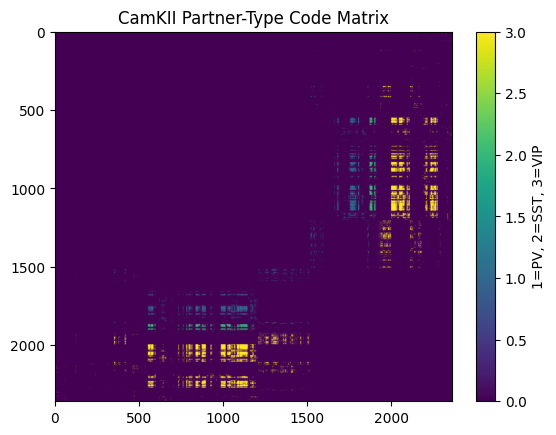

In [29]:
# English implementation note.
plt.imshow(camkii_partner_code, cmap='viridis', aspect='auto')
plt.title('CamKII Partner-Type Code Matrix')
plt.colorbar(label='1=PV, 2=SST, 3=VIP')
plt.show()


In [30]:
edge_counts = []
for idx, cell in enumerate(channel_names):
    count = int(camkii_edge_counts[:, idx].sum())
    print(f'CamkII ⇄ {cell} connections count: {count}')
    edge_counts.append({'cell_type': cell, 'count': count})

edge_counts = pd.DataFrame(edge_counts)
edge_counts.to_csv(
    os.path.join(os.path.dirname(OUTPUT_FILE_PATH), f'{event_type}_CamkII_edge_counts.csv'),
    index=False
)

print('Per-node CamKII RGB composition preview:')
display(composition_df.head())


CamkII ⇄ PV connections count: 15399
CamkII ⇄ SST connections count: 6457
CamkII ⇄ VIP connections count: 38229
Per-node CamKII RGB composition preview:


,Cell_ID,celltype,PV_edges,SST_edges,VIP_edges,Total_labeled_edges,PV_proportion,SST_proportion,VIP_proportion
0,0,1,1,0,2,3,0.333333,0.0,0.666667
1,1,1,1,0,0,1,1.000000,0.0,0.000000
2,2,1,1,0,3,4,0.250000,0.0,0.750000
3,3,1,0,0,0,0,0.000000,0.0,0.000000
4,4,1,0,0,0,0,0.000000,0.0,0.000000


Saved node-count-normalized CamKII edge table to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_edge_counts_normalized_by_target_node_count.csv


,target_celltype,target_celltype_code,raw_camkii_edge_count,target_node_count,edge_count_per_target_node,normalized_fraction,normalized_percent
0,PV,2,15399,341,45.158358,0.202756,20.275634
1,SST,3,6457,73,88.452055,0.397141,39.714054
2,VIP,4,38229,429,89.111888,0.400103,40.010312


Saved normalized pie chart to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_edge_composition_normalized_by_target_node_count_pie.pdf
Saved normalized pie chart to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_CamKII_edge_composition_normalized_by_target_node_count_pie.png


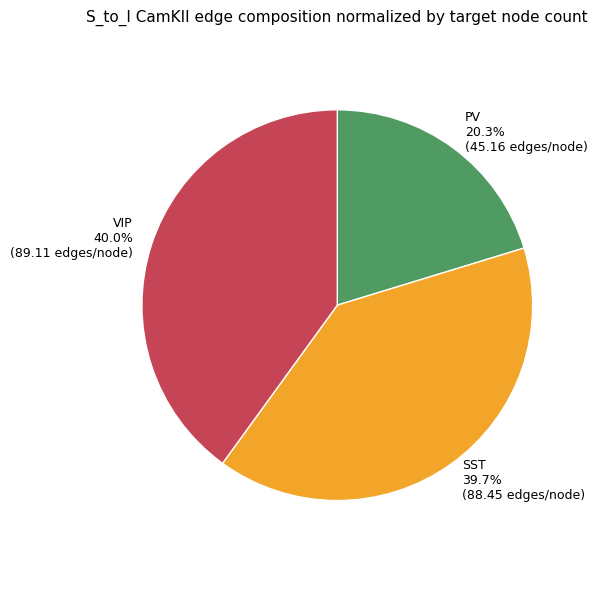

In [31]:
# ------------------------------
# 9. Node-count-normalized CamKII edge composition pie chart
# ------------------------------
# Raw CamKII-PV/SST/VIP edge counts are affected by the total number of PV/SST/VIP nodes.
# Here each subtype edge count is divided by that subtype's node count first, then normalized
# across PV/SST/VIP for a composition-style pie chart.

subtype_to_celltype = {
    'PV': 2,
    'SST': 3,
    'VIP': 4,
}

normalized_pie_rows = []
for channel_idx, subtype_name in enumerate(channel_names):
    subtype_code = subtype_to_celltype[subtype_name]
    raw_edge_count = int(camkii_edge_counts[:, channel_idx].sum())
    subtype_node_count = int(np.sum(cell_types == subtype_code))

    if subtype_node_count == 0:
        print(f"[fallback] {subtype_name} node count is 0; edge_per_node set to 0.")
        edge_per_node = 0.0
    else:
        edge_per_node = raw_edge_count / subtype_node_count

    normalized_pie_rows.append({
        'target_celltype': subtype_name,
        'target_celltype_code': subtype_code,
        'raw_camkii_edge_count': raw_edge_count,
        'target_node_count': subtype_node_count,
        'edge_count_per_target_node': edge_per_node,
    })

camkii_node_normalized_edge_df = pd.DataFrame(normalized_pie_rows)
normalization_total = camkii_node_normalized_edge_df['edge_count_per_target_node'].sum()

if normalization_total <= 0:
    print('[fallback] all node-count-normalized edge counts are 0; normalized fractions set to 0.')
    camkii_node_normalized_edge_df['normalized_fraction'] = 0.0
else:
    camkii_node_normalized_edge_df['normalized_fraction'] = (
        camkii_node_normalized_edge_df['edge_count_per_target_node'] / normalization_total
    )

camkii_node_normalized_edge_df['normalized_percent'] = camkii_node_normalized_edge_df['normalized_fraction'] * 100

normalized_edge_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_CamKII_edge_counts_normalized_by_target_node_count.csv'
)
camkii_node_normalized_edge_df.to_csv(normalized_edge_output_path, index=False, encoding='utf-8-sig')
print(f'Saved node-count-normalized CamKII edge table to {normalized_edge_output_path}')
display(camkii_node_normalized_edge_df)

fig, ax = plt.subplots(figsize=(6, 6))
pie_values = camkii_node_normalized_edge_df['normalized_fraction'].to_numpy()
pie_labels = [
    f"{row.target_celltype}\n{row.normalized_percent:.1f}%\n({row.edge_count_per_target_node:.2f} edges/node)"
    for row in camkii_node_normalized_edge_df.itertuples(index=False)
]
pie_colors = [channel_colors[name] for name in camkii_node_normalized_edge_df['target_celltype']]

if pie_values.sum() > 0:
    ax.pie(
        pie_values,
        labels=pie_labels,
        colors=pie_colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.0},
        textprops={'fontsize': 9},
    )
else:
    ax.text(0.5, 0.5, 'No normalized edges to plot', ha='center', va='center', transform=ax.transAxes)

ax.set_title(
    f'{event_type} CamKII edge composition normalized by target node count',
    fontsize=11,
)
ax.axis('equal')
plt.tight_layout()

normalized_pie_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_CamKII_edge_composition_normalized_by_target_node_count_pie'
)
# plt.savefig(f'{normalized_pie_output_path}.pdf', bbox_inches='tight')
# plt.savefig(f'{normalized_pie_output_path}.png', dpi=300, bbox_inches='tight')
print(f'Saved normalized pie chart to {normalized_pie_output_path}.pdf')
print(f'Saved normalized pie chart to {normalized_pie_output_path}.png')
plt.show()




⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含124043条有效连接


,celltype_code,celltype_name,n_total_cells,n_cells_without_camkii_connection,fraction_without_camkii_connection
0,1,CamKII,1516,555,0.366095
1,2,PV,341,80,0.234604
2,3,SST,73,12,0.164384
3,4,VIP,429,44,0.102564


,Cell_Index,celltype_code,celltype_name,n_edges_to_camkii,has_camkii_connection
10,10,1,CamKII,0,False
11,11,1,CamKII,0,False
12,12,1,CamKII,0,False
13,13,1,CamKII,0,False
14,14,1,CamKII,0,False


Saved summary table to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_cells_without_CamKII_connection_by_celltype.csv
Saved cell-level table to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_cells_without_CamKII_connection_cell_level.csv
Saved bar plot to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_cells_without_CamKII_connection_by_celltype_bar.pdf
Saved bar plot to G:\XJN_M2project\correlation_analysis\allcelltypes\S_to_I_cells_without_CamKII_connection_by_celltype_bar.png


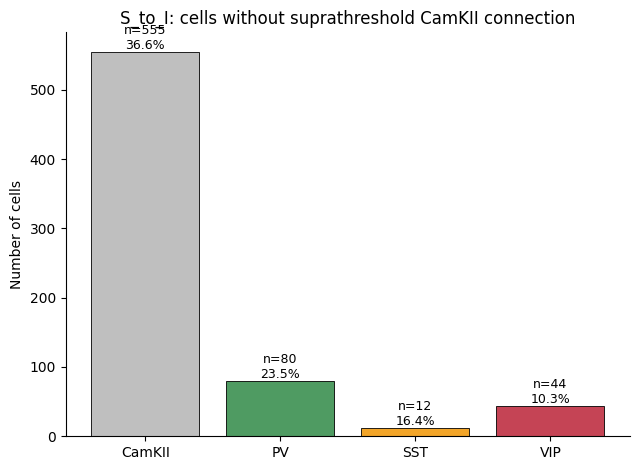

In [32]:
# ------------------------------
# 10. Cells without suprathreshold connections to CamKII
# ------------------------------
# For each cell, count how many thresholded edges connect it to any CamKII node.
# Cells with zero CamKII-connected edges are summarized by cell type.

celltype_name_map = {
    1: 'CamKII',
    2: 'PV',
    3: 'SST',
    4: 'VIP',
}
celltype_bar_color_map = {
    1: '#BFBFBF',
    2: channel_colors.get('PV', '#4F9B62'),
    3: channel_colors.get('SST', '#F2A529'),
    4: channel_colors.get('VIP', '#C54455'),
}

# Always rebuild the full thresholded adjacency matrix here.
# This avoids using a later subsetted adjacency_matrix with lonely nodes removed.
full_adjacency_matrix = binarize_matrix(data.values, mask_2d)

full_cell_types = np.asarray(cell_types)
camkii_nodes_full = np.where(full_cell_types == 1)[0]

if full_adjacency_matrix.shape[0] != len(full_cell_types):
    raise ValueError(
        f"Length mismatch: full_adjacency_matrix has {full_adjacency_matrix.shape[0]} nodes, "
        f"but cell_types has {len(full_cell_types)} entries."
    )

if len(camkii_nodes_full) == 0:
    print('[fallback] no CamKII nodes found; CamKII connection counts are set to 0 for all cells.')
    camkii_neighbor_counts = np.zeros(len(full_cell_types), dtype=int)
else:
    camkii_neighbor_counts = full_adjacency_matrix[:, camkii_nodes_full].sum(axis=1).astype(int)

camkii_connection_status_df = pd.DataFrame({
    'Cell_Index': np.arange(len(full_cell_types)),
    'celltype_code': full_cell_types,
    'celltype_name': [celltype_name_map.get(int(ct), f'Unknown_{ct}') for ct in full_cell_types],
    'n_edges_to_camkii': camkii_neighbor_counts,
})
camkii_connection_status_df['has_camkii_connection'] = camkii_connection_status_df['n_edges_to_camkii'] > 0

no_camkii_connection_df = camkii_connection_status_df.loc[
    ~camkii_connection_status_df['has_camkii_connection']
].copy()

no_camkii_summary_df = (
    no_camkii_connection_df
    .groupby(['celltype_code', 'celltype_name'], as_index=False)
    .size()
    .rename(columns={'size': 'n_cells_without_camkii_connection'})
)

all_type_counts_df = (
    camkii_connection_status_df
    .groupby(['celltype_code', 'celltype_name'], as_index=False)
    .size()
    .rename(columns={'size': 'n_total_cells'})
)

no_camkii_summary_df = all_type_counts_df.merge(
    no_camkii_summary_df,
    on=['celltype_code', 'celltype_name'],
    how='left',
)

no_camkii_summary_df['n_cells_without_camkii_connection'] = (
    no_camkii_summary_df['n_cells_without_camkii_connection'].fillna(0).astype(int)
)
no_camkii_summary_df['fraction_without_camkii_connection'] = (
    no_camkii_summary_df['n_cells_without_camkii_connection'] / no_camkii_summary_df['n_total_cells']
)
no_camkii_summary_df = no_camkii_summary_df.sort_values('celltype_code').reset_index(drop=True)

display(no_camkii_summary_df)
display(no_camkii_connection_df.head())

summary_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_cells_without_CamKII_connection_by_celltype.csv'
)
cell_level_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_cells_without_CamKII_connection_cell_level.csv'
)

no_camkii_summary_df.to_csv(summary_output_path, index=False, encoding='utf-8-sig')
no_camkii_connection_df.to_csv(cell_level_output_path, index=False, encoding='utf-8-sig')

print(f'Saved summary table to {summary_output_path}')
print(f'Saved cell-level table to {cell_level_output_path}')

fig, ax = plt.subplots(figsize=(6.5, 4.8))

bar_colors = [
    celltype_bar_color_map.get(int(code), '#808080')
    for code in no_camkii_summary_df['celltype_code']
]

bars = ax.bar(
    no_camkii_summary_df['celltype_name'],
    no_camkii_summary_df['n_cells_without_camkii_connection'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.6,
)

ax.set_ylabel('Number of cells')
ax.set_title(f'{event_type}: cells without suprathreshold CamKII connection')
ax.spines[['top', 'right']].set_visible(False)

for bar, row in zip(bars, no_camkii_summary_df.itertuples(index=False)):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'n={int(row.n_cells_without_camkii_connection)}\n{row.fraction_without_camkii_connection:.1%}',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()

bar_output_path = os.path.join(
    Path(OUTPUT_FILE_PATH).parent,
    f'{event_type}_cells_without_CamKII_connection_by_celltype_bar'
)

plt.savefig(f'{bar_output_path}.pdf', bbox_inches='tight')
plt.savefig(f'{bar_output_path}.png', dpi=300, bbox_inches='tight')

print(f'Saved bar plot to {bar_output_path}.pdf')
print(f'Saved bar plot to {bar_output_path}.png')

plt.show()